In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from GitHub_QM.Quantum_Batteries_Scars.paper.helper.quantumScarFunctions import *

In [4]:
N = 4
wd = 0.6366896896896898
tlist = np.linspace(0, 50, 150)
dlist = np.linspace(0, 4, 21)
alist = np.linspace(0.1, 4, 20)
reals = 25

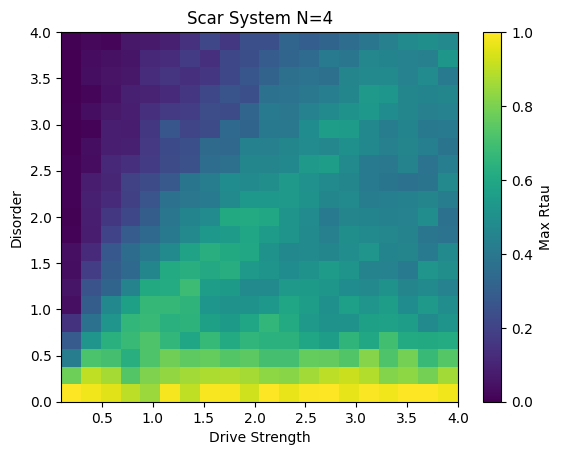

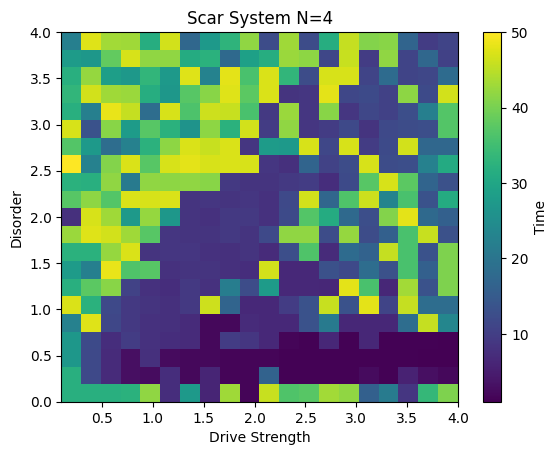

In [5]:
maxRtau = []
maxRtau_time = []

H0_clean, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)

for d in dlist:
    temp_Rtau = []
    temp_time = []
    for a in alist:
        Rtau = 0.0
        
        for _ in range(reals):
            H0, eigenvalues_dis, eigenstates_dis = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[d, 0, 0])
            args = {"A": a, "omega": wd}
            H = qt.QobjEvo([H0, [H1, coeff]], args=args)
            psi_t = qt.sesolve(H, eigenstates_dis[0], tlist, e_ops=[H0])
            Rtau += np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues_dis[-1] - eigenvalues_dis[0])

        Rtau = Rtau / reals
        temp_Rtau.append(np.max(Rtau))
        temp_time.append(tlist[np.argmax(Rtau)])

    maxRtau.append(temp_Rtau)
    maxRtau_time.append(temp_time)

plt.imshow(maxRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Max Rtau")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

plt.imshow(maxRtau_time,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Time")
plt.title(f"Scar System N={N}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

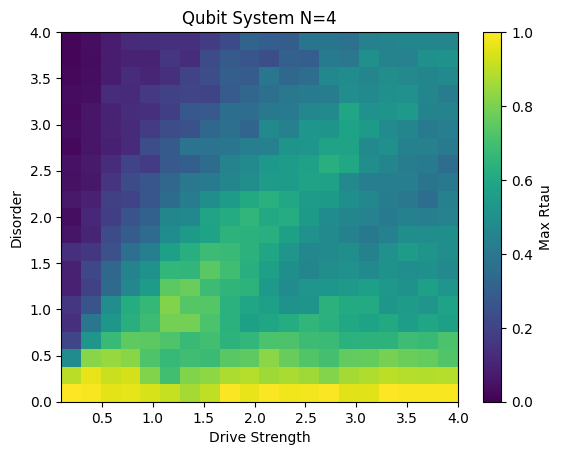

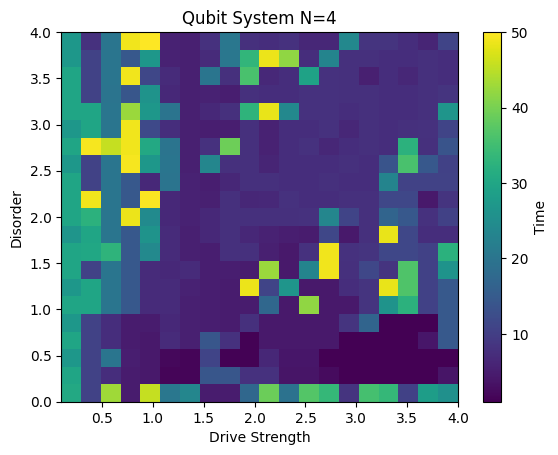

In [7]:
qN = 4
wm = 1.0
qmaxRtau = []
qmaxRtau_time = []

for d in dlist:
    temp_qRtau = []
    temp_qtime = []

    for a in alist:
        Rtau = 0.0

        for _ in range(reals):
            qH0_list, qH1_list, driveWeights = get_qubit_ham(N, wm=wm, ham_disorder=[d, 0, 0])
            dE_tot = 0
            bw_tot = 0

            for qH0, qH1 in zip(qH0_list, qH1_list):
                qeigenvalues, qeigenstates = qH0.eigenstates()
                bw_tot += qeigenvalues[-1] - qeigenvalues[0]

                qargs = {"A": a, "omega": wm}
                qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
                qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
                dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

            Rtau += dE_tot / bw_tot

        Rtau = Rtau / reals
        temp_qRtau.append(np.max(Rtau))
        temp_qtime.append(tlist[np.argmax(Rtau)])

    qmaxRtau.append(temp_qRtau)
    qmaxRtau_time.append(temp_qtime)

plt.imshow(qmaxRtau,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label="Max Rtau")
plt.title(f"Qubit System N={qN}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()

plt.imshow(qmaxRtau_time,
           extent=[alist.min(), alist.max(), dlist.min(), dlist.max()],
           origin='lower',
           aspect='auto',
           cmap='viridis')
plt.colorbar(label="Time")
plt.title(f"Qubit System N={qN}")
plt.ylabel("Disorder")
plt.xlabel("Drive Strength")
plt.show()